# 🧮 Veri Yapıları ve Algoritmalar
## Hafta: Divide & Conquer | Merge Sort | Quick Sort

---

| **Önkoşul** | Recursion, Big-O notation |

### 📋 Ders Planı

| Bölüm | Konu | Süre |
|-------|------|------|
| 1 | Divide & Conquer Paradigması | 20 dk |
| 2 | Merge Sort | 35 dk |
| 3 | Quick Sort | 35 dk |
| 4 | Karşılaştırma & Analiz | 15 dk |
| 5 | Alıştırmalar | 15 dk |

---
## 📦 Gerekli Kütüphaneler

In [1]:
import random
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from copy import deepcopy

# Görselleştirme ayarları
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("✅ Kütüphaneler yüklendi!")

✅ Kütüphaneler yüklendi!


---
# 🔷 BÖLÜM 1: Divide & Conquer Paradigması
### ⏱️ (~20 dakika)

## 1.1 Temel Fikir

**Divide & Conquer (Böl ve Fethet)** yaklaşımı 3 adımdan oluşur:

```
┌─────────────────────────────────────────────────┐
│                                                 │
│  1. DIVIDE   → Problemi daha küçük alt          │
│                problemlere böl                  │
│                                                 │
│  2. CONQUER  → Alt problemleri (recursion ile)  │
│                çöz                              │
│                                                 │
│  3. COMBINE  → Alt problemlerin çözümlerini     │
│                birleştirerek ana çözümü elde et │
│                                                 │
└─────────────────────────────────────────────────┘
```

## 1.2 Gerçek Hayat Analojisi

> 🗺️ **Harita problemi:** 1000 kişinin yaşadığı şehirde kayıp bir çocuğu aramak
> - **Naive:** Tek tek her evi ziyaret et → O(n)
> - **D&C:** Şehri bölgelere böl, her bölgeye ekip gönder, sonuçları birleştir

## 1.3 D&C'nin Matematiksel Temeli: Recurrence Relations

In [2]:
# D&C'nin en basit örneği: Binary Search
# T(n) = T(n/2) + O(1)  →  O(log n)

def binary_search(arr, target, low=0, high=None, depth=0):
    """D&C örneği: Binary Search"""
    if high is None:
        high = len(arr) - 1
    
    indent = "  " * depth
    print(f"{indent}🔍 Aranan: {target} | Bakılan aralık: {arr[low:high+1]}")
    
    # BASE CASE
    if low > high:
        print(f"{indent}❌ Bulunamadı")
        return -1
    
    mid = (low + high) // 2
    
    # DIVIDE: ortayı bul
    if arr[mid] == target:
        print(f"{indent}✅ Bulundu! Index: {mid}")
        return mid
    elif arr[mid] < target:
        print(f"{indent}→ Sağ yarıya git (arr[{mid}]={arr[mid]} < {target})")
        return binary_search(arr, target, mid + 1, high, depth + 1)  # CONQUER
    else:
        print(f"{indent}← Sol yarıya git (arr[{mid}]={arr[mid]} > {target})")
        return binary_search(arr, target, low, mid - 1, depth + 1)  # CONQUER

arr = [2, 5, 8, 12, 16, 23, 38, 42, 55, 72]
print(f"Dizi: {arr}")
print(f"Eleman sayısı: {len(arr)}")
print("="*50)
binary_search(arr, 23)

Dizi: [2, 5, 8, 12, 16, 23, 38, 42, 55, 72]
Eleman sayısı: 10
🔍 Aranan: 23 | Bakılan aralık: [2, 5, 8, 12, 16, 23, 38, 42, 55, 72]
→ Sağ yarıya git (arr[4]=16 < 23)
  🔍 Aranan: 23 | Bakılan aralık: [23, 38, 42, 55, 72]
  ← Sol yarıya git (arr[7]=42 > 23)
    🔍 Aranan: 23 | Bakılan aralık: [23, 38]
    ✅ Bulundu! Index: 5


5

## 1.4 Zaman Karmaşıklığını Sezgisel Anlamak

### 🤔 `log n` ne demek?

> **log₂(n)** = "n'i 1'e ulaşana kadar kaç kez 2'ye bölebilirim?"

```
n = 8   →  8 → 4 → 2 → 1   (3 adım)   log₂(8)  = 3
n = 16  →  16 → 8 → 4 → 2 → 1  (4 adım)   log₂(16) = 4
n = 1.000.000  →  sadece 20 adım!   log₂(1M) ≈ 20
```

### 🤔 `n log n` ne demek?

> Her bölme seviyesinde toplam n iş yapıyoruz, log n seviye var → **n × log n**

```
n = 8 elemanlı dizi için Merge Sort:

  Seviye 0:  [........]           → 8 iş   (tüm diziyi merge et)
  Seviye 1:  [....][....]         → 8 iş   (4+4 merge et)
  Seviye 2:  [..][..][..][..]     → 8 iş   (2+2+2+2 merge et)
  Seviye 3:  [.][.][.][.][.][.][.][.]  → 8 iş   (base case)
             ↑
             log₂(8) = 3 seviye

  Toplam: 4 seviye × 8 iş = 32 ≈ n log n = 8 × 3 = 24  ✓
```

### 📊 Sayılarla karşılaştırma:

| n (eleman) | O(n²) | O(n log n) | O(n) | O(log n) |
|-----------|-------|-----------|------|----------|
| 10 | 100 | 33 | 10 | 3 |
| 1.000 | 1.000.000 | 10.000 | 1.000 | 10 |
| 1.000.000 | 10¹² | 20.000.000 | 1.000.000 | 20 |

> 💡 1 milyon elemanlı bir dizide O(n²) ile O(n log n) arasındaki fark:
> **50.000 kat!**

In [ ]:
# log n'i somut sayılarla anlayalım

print("n elemanı ikiye böldüğünüzde kaç adımda 1'e ulaşırsınız?")
print("-" * 50)
for n in [8, 16, 64, 1_000, 1_000_000, 1_000_000_000]:
    steps = 0
    x = n
    while x > 1:
        x //= 2
        steps += 1
    print(f"  n = {n:>15,}  →  {steps:>2} adım  (log₂ ≈ {steps})")

print()
print("💡 1 MİLYAR elemanı sıralamak için sadece 30 seviye yeterli!")

n elemanı ikiye böldüğünüzde kaç adımda 1'e ulaşırsınız?
--------------------------------------------------
  n =               8  →   3 adım  (log₂ ≈ 3)
  n =              16  →   4 adım  (log₂ ≈ 4)
  n =              64  →   6 adım  (log₂ ≈ 6)
  n =           1,000  →   9 adım  (log₂ ≈ 9)
  n =       1,000,000  →  19 adım  (log₂ ≈ 19)
  n =   1,000,000,000  →  29 adım  (log₂ ≈ 29)

💡 1 MİLYAR elemanı sıralamak için sadece 30 seviye yeterli!


C:\Users\murat.simav\AppData\Local\Temp\1\ipykernel_27232\1240067689.py:29: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


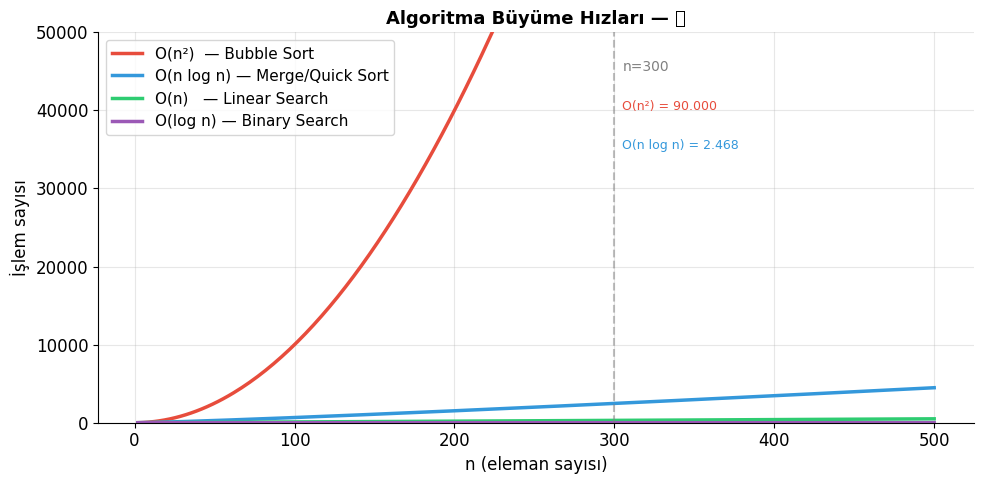

In [22]:
# Büyüme hızlarını grafik ile karşılaştır
import numpy as np
import matplotlib.pyplot as plt

n = np.linspace(2, 500, 300)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(n, n**2,            label='O(n²)  — Bubble Sort',  color='#E74C3C', linewidth=2.5)
ax.plot(n, n * np.log2(n),  label='O(n log n) — Merge/Quick Sort', color='#3498DB', linewidth=2.5)
ax.plot(n, n,               label='O(n)   — Linear Search', color='#2ECC71', linewidth=2.5)
ax.plot(n, np.log2(n),      label='O(log n) — Binary Search', color='#9B59B6', linewidth=2.5)

ax.set_xlabel('n (eleman sayısı)', fontsize=12)
ax.set_ylabel('İşlem sayısı', fontsize=12)
ax.set_title('Algoritma Büyüme Hızları — 🧠', fontsize=13, fontweight='bold')
ax.set_ylim(0, 50000)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# n=300 anında farkı göster
ax.axvline(x=300, color='gray', linestyle='--', alpha=0.5)
ax.text(305, 45000, 'n=300', color='gray', fontsize=10)
ax.text(305, 40000, f'O(n²) = 90.000', color='#E74C3C', fontsize=9)
ax.text(305, 35000, f'O(n log n) = 2.468', color='#3498DB', fontsize=9)

plt.tight_layout()
plt.show()

---
# 🔷 BÖLÜM 2: Merge Sort
### ⏱️ (~35 dakika)

## 2.1 Algoritma Fikri

```
Dizi: [38, 27, 43, 3, 9, 82, 10]

         DIVIDE (Böl)
         ↓
[38, 27, 43, 3]        [9, 82, 10]
[38, 27]  [43, 3]    [9, 82]  [10]
[38] [27] [43] [3]  [9] [82]  [10]

         MERGE (Birleştir)
         ↑
[27, 38]  [3, 43]    [9, 82]  [10]
[3, 27, 38, 43]      [9, 10, 82]
      [3, 9, 10, 27, 38, 43, 82]
```

In [ ]:
# Adım 1: Merge (Birleştirme) fonksiyonu - Merge Sort'un kalbi

def merge(left, right):
    """
    İki sıralı diziyi birleştirerek sıralı bir dizi döndürür.
    Zaman: O(n), Alan: O(n)
    """
    result = []
    i = j = 0
    
    # İki pointer'ı karşılaştırarak küçüğü al
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:   # Eşitlikte sol önce gelir 
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    
    # Kalan elemanları ekle
    result.extend(left[i:])
    result.extend(right[j:])
    
    return result

# Merge fonksiyonunu test edelim
left  = [3, 27, 38, 43]
right = [9, 10, 82]

print(f"Sol  dizi: {left}")
print(f"Sağ  dizi: {right}")
print(f"Birleşim : {merge(left, right)}")

Sol  dizi: [3, 27, 38, 43]
Sağ  dizi: [9, 10, 82]
Birleşim : [3, 9, 10, 27, 38, 43, 82]


In [6]:
# Adım 2: Merge Sort - ana fonksiyon

def merge_sort(arr, depth=0):
    """
    Merge Sort implementasyonu.
    Zaman: O(n log n) - her durumda
    Alan:  O(n)       - ekstra bellek gerektirir
    Stable: Evet
    """
    indent = "  " * depth
    
    # BASE CASE: 0 veya 1 elemanlı dizi zaten sıralıdır
    if len(arr) <= 1:
        return arr
    
    print(f"{indent}📂 DIVIDE: {arr}")
    
    # DIVIDE: Ortadan ikiye böl
    mid = len(arr) // 2
    left_half  = arr[:mid]
    right_half = arr[mid:]
    
    # CONQUER: Rekürsif olarak sırala
    left_sorted  = merge_sort(left_half,  depth + 1)
    right_sorted = merge_sort(right_half, depth + 1)
    
    # COMBINE: Birleştir
    merged = merge(left_sorted, right_sorted)
    print(f"{indent}🔗 MERGE:  {left_sorted} + {right_sorted} → {merged}")
    
    return merged

print("=" * 55)
arr = [38, 27, 43, 3, 9, 82, 10]
print(f"Başlangıç: {arr}")
print("=" * 55)
sorted_arr = merge_sort(arr)
print("=" * 55)
print(f"Sonuç    : {sorted_arr}")

Başlangıç: [38, 27, 43, 3, 9, 82, 10]
📂 DIVIDE: [38, 27, 43, 3, 9, 82, 10]
  📂 DIVIDE: [38, 27, 43]
    📂 DIVIDE: [27, 43]
    🔗 MERGE:  [27] + [43] → [27, 43]
  🔗 MERGE:  [38] + [27, 43] → [27, 38, 43]
  📂 DIVIDE: [3, 9, 82, 10]
    📂 DIVIDE: [3, 9]
    🔗 MERGE:  [3] + [9] → [3, 9]
    📂 DIVIDE: [82, 10]
    🔗 MERGE:  [82] + [10] → [10, 82]
  🔗 MERGE:  [3, 9] + [10, 82] → [3, 9, 10, 82]
🔗 MERGE:  [27, 38, 43] + [3, 9, 10, 82] → [3, 9, 10, 27, 38, 43, 82]
Sonuç    : [3, 9, 10, 27, 38, 43, 82]


In [8]:
# Production-grade Merge Sort (verbose olmayan, temiz versiyon)

def merge_sort_clean(arr):
    """Temiz, production-ready Merge Sort implementasyonu."""
    if len(arr) <= 1:
        return arr
    
    mid = len(arr) // 2
    left  = merge_sort_clean(arr[:mid])
    right = merge_sort_clean(arr[mid:])
    
    return merge(left, right)

# Test
test_cases = [
    [5, 2, 4, 6, 1, 3],
    [1],
    [],
    [3, 3, 3, 1, 1],
    list(range(10, 0, -1))
]

print("Merge Sort Test Sonuçları:")
print("-" * 40)
for tc in test_cases:
    result = merge_sort_clean(tc)
    print(f"  Girdi : {tc}")
    print(f"  Çıktı : {result}")
    print()

Merge Sort Test Sonuçları:
----------------------------------------
  Girdi : [5, 2, 4, 6, 1, 3]
  Çıktı : [1, 2, 3, 4, 5, 6]

  Girdi : [1]
  Çıktı : [1]

  Girdi : []
  Çıktı : []

  Girdi : [3, 3, 3, 1, 1]
  Çıktı : [1, 1, 3, 3, 3]

  Girdi : [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
  Çıktı : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]



## 2.2 Merge Sort — Zaman Karmaşıklığı

### Sezgisel Açıklama (Formülsüz)

```
Dizi: [38, 27, 43, 3, 9, 82, 10]   (n = 7 eleman)

┌─────────────────────────────────────────────────────────┐
│ Seviye 0 │  [38, 27, 43, 3, 9, 82, 10]  → 7 karşılaştırma  │
│ Seviye 1 │  [38,27,43,3]  [9,82,10]     → 7 karşılaştırma  │
│ Seviye 2 │  [38,27][43,3] [9,82][10]    → 7 karşılaştırma  │
│ Seviye 3 │  [38][27][43][3][9][82][10]  → base case         │
└─────────────────────────────────────────────────────────┘
       Her seviyede toplam ≈ n iş yapılır!
       Seviye sayısı = kaç kez ikiye bölebildiğimiz = log₂(n)

       Sonuç: n seviye başına iş × log n seviye = O(n log n)
```

### Neden her seviyede toplam n iş var?

```
Seviye 1'de 2 parça var: her biri n/2 eleman → 2 × (n/2) = n  ✓
Seviye 2'de 4 parça var: her biri n/4 eleman → 4 × (n/4) = n  ✓
Seviye k'da 2^k parça var: her biri n/2^k    → her zaman n    ✓
```

| Durum | Karmaşıklık | Neden? |
|-------|------------|--------|
| En İyi | **O(n log n)** | Her zaman ortadan böler |
| Ortalama | **O(n log n)** | Her zaman ortadan böler |
| En Kötü | **O(n log n)** | Her zaman ortadan böler |
| Alan (Space) | **O(n)** | Merge için ekstra dizi lazım |

> ⭐ Merge Sort'un gücü: bölme noktası değişmez, **her durumda** O(n log n) garantisi var.
> - **Stable Sort:** Eşit elemanların sırası korunur
> - **Not In-place:** Ekstra O(n) bellek kullanır

---
# 🔷 BÖLÜM 3: Quick Sort
### ⏱️ (~35 dakika)

## 3.1 Temel Fikir: Pivot Seçimi

```
Dizi: [3, 6, 8, 10, 1, 2, 1]  →  Pivot: 6 seçildi

PARTITION sonrası:
[ 3, 1, 2, 1 ] | [6] | [ 8, 10 ]
  (pivot'tan      pivot   (pivot'tan
   küçükler)             büyükler)

Rekürsif olarak sol ve sağ tarafları sırala!
```

## 3.2 Partition Algoritması (Lomuto Scheme)

In [9]:
# Partition fonksiyonu - Quick Sort'un kalbi

def partition_lomuto(arr, low, high):
    """
    Lomuto partition scheme.
    Son elemanı pivot olarak seçer.
    Pivot'u doğru konumuna yerleştirir.
    Returns: pivot'un final indexi
    """
    pivot = arr[high]  # Son elemanı pivot seç
    i = low - 1        # i: pivot'tan küçük bölgenin sonu
    
    print(f"  Pivot: {pivot} | Dizi: {arr[low:high+1]}")
    
    for j in range(low, high):
        if arr[j] <= pivot:    # Eleman pivot'tan küçük/eşitse
            i += 1
            arr[i], arr[j] = arr[j], arr[i]   # Swap!
            print(f"    j={j}: arr[j]={arr[j]} ≤ pivot={pivot} → swap({i},{j}): {arr[low:high+1]}")
    
    # Pivot'u doğru yerine koy
    arr[i + 1], arr[high] = arr[high], arr[i + 1]
    pivot_index = i + 1
    print(f"  Pivot {pivot} → index {pivot_index} | Sonuç: {arr[low:high+1]}")
    
    return pivot_index

# Demo
arr = [3, 6, 8, 10, 1, 2, 1]
print(f"Başlangıç: {arr}")
print("Partition işlemi:")
pi = partition_lomuto(arr, 0, len(arr)-1)
print(f"Sonuç: {arr}")
print(f"Pivot index: {pi} → arr[{pi}] = {arr[pi]}")

Başlangıç: [3, 6, 8, 10, 1, 2, 1]
Partition işlemi:
  Pivot: 1 | Dizi: [3, 6, 8, 10, 1, 2, 1]
    j=4: arr[j]=3 ≤ pivot=1 → swap(0,4): [1, 6, 8, 10, 3, 2, 1]
  Pivot 1 → index 1 | Sonuç: [1, 1, 8, 10, 3, 2, 6]
Sonuç: [1, 1, 8, 10, 3, 2, 6]
Pivot index: 1 → arr[1] = 1


In [10]:
# Quick Sort - tam implementasyon (verbose)

def quick_sort_verbose(arr, low, high, depth=0):
    """
    Quick Sort (verbose - adım adım)
    """
    indent = "  " * depth
    
    if low < high:
        print(f"{indent}📍 quicksort({arr[low:high+1]})")
        
        # DIVIDE: Partition ile pivot'u yerine koy
        pivot_idx = partition_lomuto(arr, low, high)
        
        # CONQUER: Sol ve sağ yarıları sırala
        quick_sort_verbose(arr, low, pivot_idx - 1, depth + 1)   # Sol
        quick_sort_verbose(arr, pivot_idx + 1, high, depth + 1)  # Sağ

arr = [3, 6, 8, 10, 1, 2, 1]
print(f"Başlangıç: {arr}")
print("=" * 55)
quick_sort_verbose(arr, 0, len(arr) - 1)
print("=" * 55)
print(f"Sonuç    : {arr}")

Başlangıç: [3, 6, 8, 10, 1, 2, 1]
📍 quicksort([3, 6, 8, 10, 1, 2, 1])
  Pivot: 1 | Dizi: [3, 6, 8, 10, 1, 2, 1]
    j=4: arr[j]=3 ≤ pivot=1 → swap(0,4): [1, 6, 8, 10, 3, 2, 1]
  Pivot 1 → index 1 | Sonuç: [1, 1, 8, 10, 3, 2, 6]
  📍 quicksort([8, 10, 3, 2, 6])
  Pivot: 6 | Dizi: [8, 10, 3, 2, 6]
    j=4: arr[j]=8 ≤ pivot=6 → swap(2,4): [3, 10, 8, 2, 6]
    j=5: arr[j]=10 ≤ pivot=6 → swap(3,5): [3, 2, 8, 10, 6]
  Pivot 6 → index 4 | Sonuç: [3, 2, 6, 10, 8]
    📍 quicksort([3, 2])
  Pivot: 2 | Dizi: [3, 2]
  Pivot 2 → index 2 | Sonuç: [2, 3]
    📍 quicksort([10, 8])
  Pivot: 8 | Dizi: [10, 8]
  Pivot 8 → index 5 | Sonuç: [8, 10]
Sonuç    : [1, 1, 2, 3, 6, 8, 10]


In [11]:
# Production-grade Quick Sort (temiz versiyon)

def quick_sort(arr, low=None, high=None):
    """Temiz, production-ready Quick Sort implementasyonu."""
    if low is None: low = 0
    if high is None: high = len(arr) - 1
    
    if low < high:
        pivot_idx = _partition(arr, low, high)
        quick_sort(arr, low, pivot_idx - 1)
        quick_sort(arr, pivot_idx + 1, high)
    return arr

def _partition(arr, low, high):
    pivot = arr[high]
    i = low - 1
    for j in range(low, high):
        if arr[j] <= pivot:
            i += 1
            arr[i], arr[j] = arr[j], arr[i]
    arr[i + 1], arr[high] = arr[high], arr[i + 1]
    return i + 1

# Test
test_cases = [
    [5, 2, 4, 6, 1, 3],
    [1],
    [],
    [3, 3, 3, 1, 1],
    list(range(10, 0, -1))
]

print("Quick Sort Test Sonuçları:")
print("-" * 40)
for tc in test_cases:
    arr_copy = tc.copy()
    result = quick_sort(arr_copy)
    print(f"  Girdi : {tc}")
    print(f"  Çıktı : {result}")
    print()

Quick Sort Test Sonuçları:
----------------------------------------
  Girdi : [5, 2, 4, 6, 1, 3]
  Çıktı : [1, 2, 3, 4, 5, 6]

  Girdi : [1]
  Çıktı : [1]

  Girdi : []
  Çıktı : []

  Girdi : [3, 3, 3, 1, 1]
  Çıktı : [1, 1, 3, 3, 3]

  Girdi : [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
  Çıktı : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]



## 3.3 Pivot Seçimi Stratejileri

Quick Sort'un performansı doğrudan pivot seçimine bağlıdır!

| Strateji | Açıklama | Risk |
|----------|----------|------|
| **Son eleman** | Basit, yaygın | Sıralı dizide O(n²) |
| **İlk eleman** | Basit | Sıralı dizide O(n²) |
| **Rastgele** | Güvenli | Küçük overhead |
| **Median-of-3** | Dengeli, yaygın | Biraz karmaşık |

In [12]:
# Randomized Quick Sort — pratikte tercih edilen versiyon

def randomized_quick_sort(arr, low=None, high=None):
    """Rastgele pivot seçimi ile Quick Sort."""
    if low is None: low = 0
    if high is None: high = len(arr) - 1
    
    if low < high:
        # Rastgele pivot seç ve son konuma taşı
        rand_idx = random.randint(low, high)
        arr[rand_idx], arr[high] = arr[high], arr[rand_idx]
        
        pivot_idx = _partition(arr, low, high)
        randomized_quick_sort(arr, low, pivot_idx - 1)
        randomized_quick_sort(arr, pivot_idx + 1, high)
    return arr

# Kötü durum testi: Sıralı dizi
sorted_arr = list(range(1, 11))
print(f"Sıralı dizi (worst case for naive pivot): {sorted_arr}")
result = randomized_quick_sort(sorted_arr.copy())
print(f"Randomized QS sonucu: {result}")
print("✅ Randomized pivot, worst-case riskini ortadan kaldırır!")

Sıralı dizi (worst case for naive pivot): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Randomized QS sonucu: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
✅ Randomized pivot, worst-case riskini ortadan kaldırır!


In [13]:
# Alternatif: Hoare Partition Scheme
# Lomuto'dan daha az swap yapar (ortalama 3x daha verimli)

def partition_hoare(arr, low, high):
    """
    Hoare partition scheme.
    İlk elemanı pivot olarak kullanır.
    Lomuto'dan daha az swap yapar!
    """
    pivot = arr[low]
    i = low - 1
    j = high + 1
    
    while True:
        i += 1
        while arr[i] < pivot:
            i += 1
        j -= 1
        while arr[j] > pivot:
            j -= 1
        if i >= j:
            return j
        arr[i], arr[j] = arr[j], arr[i]

def quick_sort_hoare(arr, low=None, high=None):
    if low is None: low = 0
    if high is None: high = len(arr) - 1
    if low < high:
        p = partition_hoare(arr, low, high)
        quick_sort_hoare(arr, low, p)
        quick_sort_hoare(arr, p + 1, high)
    return arr

arr = [3, 6, 8, 10, 1, 2, 1]
result = quick_sort_hoare(arr.copy())
print(f"Hoare Partition Quick Sort: {arr} → {result}")

Hoare Partition Quick Sort: [3, 6, 8, 10, 1, 2, 1] → [1, 1, 2, 3, 6, 8, 10]


## 3.4 Quick Sort — Zaman Karmaşıklığı

### ✅ İyi durum — O(n log n)

```
Pivot her seferinde tam ortayı seçerse:

  [1  2  3  4  5  6  7  8]   → pivot=4, 8 karşılaştırma
  [1  2  3] | 4 | [5  6  7  8]  → pivot=2 ve 6, toplam 8
  [1][2][3] | 4 | [5][6][7][8]  → base case

  Seviye sayısı = log n  →  her seviyede n iş  →  O(n log n)
```

### ❌ Kötü durum — O(n²)

```
Pivot her seferinde en küçük eleman seçilirse:

  [1, 2, 3, 4, 5]   → pivot=1, 4 karşılaştırma
     [2, 3, 4, 5]   → pivot=2, 3 karşılaştırma
        [3, 4, 5]   → pivot=3, 2 karşılaştırma
           [4, 5]   → pivot=4, 1 karşılaştırma

  Toplam: 4+3+2+1 = n(n-1)/2 ≈ O(n²)  💀

  Bu durum ne zaman olur?
  → Zaten sıralı dizi + son/ilk eleman pivot seçimi
  → Çözüm: Rastgele pivot (Randomized Quick Sort)
```

| Durum | Karmaşıklık | Ne zaman? |
|-------|------------|----------|
| En İyi | **O(n log n)** | Pivot hep ortayı seçer |
| Ortalama | **O(n log n)** | Rastgele veriler |
| En Kötü | **O(n²)** | Sıralı dizi + naif pivot |
| Alan (Space) | **O(log n)** | Sadece call stack |

---
# 🔷 BÖLÜM 4: Karşılaştırma & Performans Analizi
### ⏱️ (~15 dakika)

In [14]:
# Performans karşılaştırması: Gerçek zamanlama

import sys
sys.setrecursionlimit(10000)

def time_sort(sort_func, arr, *args):
    """Bir sıralama fonksiyonunun çalışma süresini ölç."""
    arr_copy = arr.copy()
    start = time.perf_counter()
    sort_func(arr_copy, *args)
    end = time.perf_counter()
    return (end - start) * 1000  # milisaniye

sizes = [100, 500, 1000, 2000, 4000]
merge_times = []
quick_times = []
python_times = []

print(f"{'N':>6} | {'Merge Sort':>12} | {'Quick Sort':>12} | {'Python sort':>12}")
print("-" * 52)

for n in sizes:
    arr = [random.randint(1, 10000) for _ in range(n)]
    
    mt = time_sort(lambda a: merge_sort_clean(a), arr)
    qt = time_sort(lambda a: quick_sort(a), arr)
    pt = time_sort(lambda a: a.sort(), arr)
    
    merge_times.append(mt)
    quick_times.append(qt)
    python_times.append(pt)
    
    print(f"{n:>6} | {mt:>10.2f}ms | {qt:>10.2f}ms | {pt:>10.2f}ms")

     N |   Merge Sort |   Quick Sort |  Python sort
----------------------------------------------------
   100 |       0.13ms |       0.06ms |       0.02ms
   500 |       0.65ms |       0.25ms |       0.04ms
  1000 |       1.06ms |       0.56ms |       0.07ms
  2000 |       1.77ms |       1.04ms |       0.15ms
  4000 |       3.90ms |       2.59ms |       0.31ms


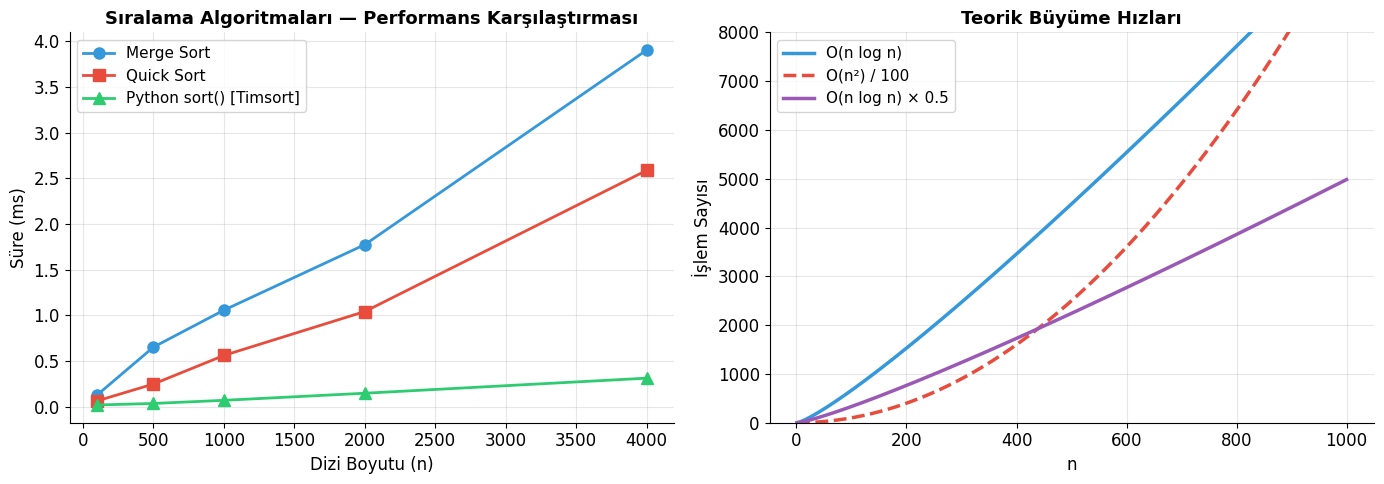

In [15]:
# Grafik karşılaştırması

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Çizgi grafik
ax1 = axes[0]
ax1.plot(sizes, merge_times, 'o-', label='Merge Sort', color='#3498DB', linewidth=2, markersize=8)
ax1.plot(sizes, quick_times, 's-', label='Quick Sort', color='#E74C3C', linewidth=2, markersize=8)
ax1.plot(sizes, python_times, '^-', label='Python sort() [Timsort]', color='#2ECC71', linewidth=2, markersize=8)
ax1.set_xlabel('Dizi Boyutu (n)', fontsize=12)
ax1.set_ylabel('Süre (ms)', fontsize=12)
ax1.set_title('Sıralama Algoritmaları — Performans Karşılaştırması', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Sağ: Teorik kompleksite karşılaştırması
ax2 = axes[1]
n = np.linspace(1, 1000, 1000)
ax2.plot(n, n * np.log2(n), label='O(n log n)', color='#3498DB', linewidth=2.5)
ax2.plot(n, n**2 / 100, label='O(n²) / 100', color='#E74C3C', linewidth=2.5, linestyle='--')
ax2.plot(n, n * np.log2(n) * 0.5, label='O(n log n) × 0.5', color='#9B59B6', linewidth=2.5)
ax2.set_xlabel('n', fontsize=12)
ax2.set_ylabel('İşlem Sayısı', fontsize=12)
ax2.set_title('Teorik Büyüme Hızları', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_ylim(0, 8000)

plt.tight_layout()
plt.show()

In [16]:
# Quick Sort'un worst case gösterimi

print("⚠️  Quick Sort Worst Case Demonstrasyonu")
print("=" * 55)

def count_operations():
    ops = {'count': 0}
    
    def quick_sort_count(arr, low=0, high=None):
        if high is None: high = len(arr) - 1
        if low < high:
            # Naive: son eleman pivot
            pivot = arr[high]
            i = low - 1
            for j in range(low, high):
                ops['count'] += 1  # karşılaştırma say
                if arr[j] <= pivot:
                    i += 1
                    arr[i], arr[j] = arr[j], arr[i]
            arr[i+1], arr[high] = arr[high], arr[i+1]
            pi = i + 1
            quick_sort_count(arr, low, pi - 1)
            quick_sort_count(arr, pi + 1, high)
    
    return quick_sort_count, ops

for n in [10, 50, 100, 200]:
    # Random dizi
    qs_rand, ops_rand = count_operations()
    arr_rand = [random.randint(1, 1000) for _ in range(n)]
    qs_rand(arr_rand)
    
    # Sıralı dizi (worst case)
    qs_worst, ops_worst = count_operations()
    arr_sorted = list(range(1, n+1))   # Zaten sıralı!
    try:
        qs_worst(arr_sorted)
        worst_count = ops_worst['count']
    except RecursionError:
        worst_count = -1
    
    rand_count = ops_rand['count']
    theoretical_avg = int(n * np.log2(n))
    theoretical_worst = n * (n-1) // 2
    
    print(f"n={n:>4}: Ortalama={rand_count:>6} karş. | "
          f"Worst={'RECURSION ERR' if worst_count==-1 else str(worst_count):>6} | "
          f"Teorik n²/2={theoretical_worst:>6}")

⚠️  Quick Sort Worst Case Demonstrasyonu
n=  10: Ortalama=    22 karş. | Worst=    45 | Teorik n²/2=    45
n=  50: Ortalama=   234 karş. | Worst=  1225 | Teorik n²/2=  1225
n= 100: Ortalama=   635 karş. | Worst=  4950 | Teorik n²/2=  4950
n= 200: Ortalama=  1502 karş. | Worst= 19900 | Teorik n²/2= 19900


## 4.1 Özet Karşılaştırma Tablosu

| Özellik | Merge Sort | Quick Sort |
|---------|-----------|----------|
| **Best Case** | O(n log n) | O(n log n) |
| **Average Case** | O(n log n) | O(n log n) |
| **Worst Case** | O(n log n) | O(n²) |
| **Space** | O(n) | O(log n) |
| **Stable** | ✅ Evet | ❌ Hayır |
| **In-place** | ❌ Hayır | ✅ Evet |
| **Cache** | Kötü | İyi |
| **Kullanım** | Linked list, dış sıralama | Genel amaçlı |

### 🤔 Ne zaman hangisini kullanmalıyım?

```
Merge Sort tercih et:
  ✓ Stable sort gerekiyorsa (aynı değerlerin sırası önemli)
  ✓ Linked list sıralanıyorsa
  ✓ Dış sıralama (disk üzerinde büyük veri)
  ✓ Worst-case garantisi önemliyse

Quick Sort tercih et:
  ✓ Array sıralanıyorsa (cache dostluğu)
  ✓ Bellek kritikse (in-place)
  ✓ Ortalama performans yeterliyse
  ✓ Pratikte genellikle Merge Sort'tan hızlıdır
```

### 💡 Gerçek hayatta ne kullanılır?
- **Python's sort():** TimSort = Merge Sort + Insertion Sort (hybrid)
- **Java Arrays.sort():** Dual-Pivot Quick Sort (primitives)
- **C++ std::sort:** Introsort = Quick Sort + Heap Sort + Insertion Sort (hybrid)

---
# 🔷 BÖLÜM 5: Alıştırmalar
### ⏱️ (~15 dakika)

Aşağıdaki alıştırmaları sınıfta birlikte yapalım. `# TODO` kısımlarını doldurun!

### 🟡 Alıştırma 1 — Kolay: Sıralama sayacı

Merge Sort'un kaç **karşılaştırma** yaptığını sayan bir versiyon yazın.

In [17]:
def merge_sort_count_comparisons(arr):
    """
    Merge Sort'u uygula ve toplam karşılaştırma sayısını döndür.
    Returns: (sorted_arr, comparison_count)
    """
    comparisons = [0]  # Liste olarak tanımla ki nested function'dan erişilebilelim
    
    def merge_count(left, right):
        result = []
        i = j = 0
        while i < len(left) and j < len(right):
            comparisons[0] += 1  # Her karşılaştırmayı say
            # TODO: merge işlemini buraya yaz
            pass
        result.extend(left[i:])
        result.extend(right[j:])
        return result
    
    def ms(arr):
        if len(arr) <= 1:
            return arr
        # TODO: merge sort'u buraya implement et
        pass
    
    sorted_arr = ms(arr)
    return sorted_arr, comparisons[0]

# Test
# arr = [5, 2, 4, 6, 1, 3]
# sorted_arr, count = merge_sort_count_comparisons(arr)
# print(f"Dizi: {arr}")
# print(f"Sıralı: {sorted_arr}")
# print(f"Karşılaştırma sayısı: {count}")
# print(f"Teorik O(n log n): {int(len(arr) * np.log2(len(arr)))}")

In [18]:
# Çözüm — açmak için hücreyi çalıştırın
SOLUTION_1 = '''
def merge_sort_count_comparisons(arr):
    comparisons = [0]
    
    def merge_count(left, right):
        result = []
        i = j = 0
        while i < len(left) and j < len(right):
            comparisons[0] += 1
            if left[i] <= right[j]:
                result.append(left[i])
                i += 1
            else:
                result.append(right[j])
                j += 1
        result.extend(left[i:])
        result.extend(right[j:])
        return result
    
    def ms(arr):
        if len(arr) <= 1:
            return arr
        mid = len(arr) // 2
        left  = ms(arr[:mid])
        right = ms(arr[mid:])
        return merge_count(left, right)
    
    sorted_arr = ms(arr)
    return sorted_arr, comparisons[0]
'''
print("📝 Çözüm:")
print(SOLUTION_1)

📝 Çözüm:

def merge_sort_count_comparisons(arr):
    comparisons = [0]

    def merge_count(left, right):
        result = []
        i = j = 0
        while i < len(left) and j < len(right):
            comparisons[0] += 1
            if left[i] <= right[j]:
                result.append(left[i])
                i += 1
            else:
                result.append(right[j])
                j += 1
        result.extend(left[i:])
        result.extend(right[j:])
        return result

    def ms(arr):
        if len(arr) <= 1:
            return arr
        mid = len(arr) // 2
        left  = ms(arr[:mid])
        right = ms(arr[mid:])
        return merge_count(left, right)

    sorted_arr = ms(arr)
    return sorted_arr, comparisons[0]



### 🔴 Alıştırma 3 — Zor: 3-Way Quick Sort (Dutch National Flag)

Standart Quick Sort, çok sayıda **tekrarlı eleman** olduğunda yavaşlar.

Diziyi 3 bölgeye ayıran Dijkstra'nın **3-way partition** algoritmasını implement edin:
```
[ pivot'tan küçükler | pivot'a eşitler | pivot'tan büyükler ]
```

In [20]:
def three_way_quick_sort(arr, low=None, high=None):
    """
    3-Way Quick Sort (Dutch National Flag partition).
    Çok sayıda tekrarlı eleman olduğunda O(n) bile olabilir!
    
    Partition sonrası:
    arr[low..lt-1]  < pivot
    arr[lt..gt]    == pivot
    arr[gt+1..high]  > pivot
    """
    if low is None: low = 0
    if high is None: high = len(arr) - 1
    
    if low < high:
        lt, gt = low, high
        pivot = arr[low]
        i = low + 1
        
        # TODO: 3-way partition implement et
        # i pointer'ını ilerlet:
        #   arr[i] < pivot  → arr[lt] ile swap, lt++, i++
        #   arr[i] == pivot → i++
        #   arr[i] > pivot  → arr[gt] ile swap, gt--
        pass
        
        three_way_quick_sort(arr, low, lt - 1)
        three_way_quick_sort(arr, gt + 1, high)
    
    return arr

# Test — çok tekrarlı eleman
arr = [3, 3, 1, 3, 2, 1, 3, 2, 2]
print(f"Başlangıç: {arr}")
# result = three_way_quick_sort(arr.copy())
# print(f"Sonuç    : {result}")

Başlangıç: [3, 3, 1, 3, 2, 1, 3, 2, 2]


---
# 📚 Özet & Temel Çıkarımlar

```
┌────────────────────────────────────────────────────────┐
│              Bu Hafta Öğrendiklerimiz                  │
├────────────────────────────────────────────────────────┤
│                                                        │
│  ✅ D&C: Böl → Çöz → Birleştir                        │
│                                                        │
│  ✅ Merge Sort                                         │
│     • O(n log n) — her zaman garantili                 │
│     • Stable, Not in-place                             │
│     • Linked list ve dış sıralamada tercih edilir      │
│                                                        │
│  ✅ Quick Sort                                         │
│     • O(n log n) ortalama, O(n²) worst case            │
│     • Not stable, In-place                             │
│     • Pratikte genellikle en hızlısı                   │
│     • Pivot seçimi kritik!                             │
│                                                        │
│  ✅ Recurrence Relations & Master Theorem              │
│                                                        │
└────────────────────────────────────────────────────────┘
```


## 🔗 Kaynaklar
- CLRS (Introduction to Algorithms) — Bölüm 2, 4, 7
- [Visualgo.net](https://visualgo.net/en/sorting) — İnteraktif görselleştirme
- [Sorting.at](https://sorting.at) — Animasyonlar

In [21]:
# Bonus: Python'un yerleşik sort() ile karşılaştırma
# (Timsort — O(n log n), hybrid Merge+Insertion Sort)

arr = [random.randint(1, 1000) for _ in range(5000)]

algorithms = {
    'Merge Sort': lambda a: merge_sort_clean(a.copy()),
    'Quick Sort': lambda a: quick_sort(a.copy()),
    'Python sort()': lambda a: sorted(a),
}

print(f"{'Algoritma':<20} {'Süre (ms)':>12}")
print("-" * 35)

for name, func in algorithms.items():
    start = time.perf_counter()
    result = func(arr)
    elapsed = (time.perf_counter() - start) * 1000
    
    # Doğruluğu kontrol et
    is_correct = result == sorted(arr)
    print(f"{name:<20} {elapsed:>10.2f}ms  {'✅' if is_correct else '❌'}")

print("\n💡 Python'un Timsort'u neden bu kadar hızlı?")
print("   → C implementasyonu + real-world optimizasyonlar")
print("   → Zaten kısmen sıralı dizilerde O(n) yaklaşır")

Algoritma               Süre (ms)
-----------------------------------
Merge Sort                 6.85ms  ✅
Quick Sort                 4.96ms  ✅
Python sort()              0.75ms  ✅

💡 Python'un Timsort'u neden bu kadar hızlı?
   → C implementasyonu + real-world optimizasyonlar
   → Zaten kısmen sıralı dizilerde O(n) yaklaşır
